# 03 — Feature Validation

**Goal:** Verify that the features we're building actually have predictive
power for the target (Utah healthcare employment).

**Analysis:**
1. Correlation matrix of all features vs. target
2. Lag analysis — at what lag do JOLTS indicators best predict UTEDUH changes?
3. Granger causality tests for key feature→target relationships
4. Feature importance ranking

**Key question:** Do national JOLTS signals actually lead Utah employment
outcomes, or is the theoretical lead-lag relationship too noisy to exploit?

In [6]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'backend'))

from dotenv import load_dotenv
load_dotenv(Path.cwd().parent / 'backend' / '.env')  # explicit path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.ingestion import generate_dummy_series
from features.preprocessing import preprocess_all
from features.engineering import build_lag_features, compute_derived_features

In [8]:
from data.ingestion import fetch_all_series

# Load and preprocess
raw = fetch_all_series()

# raw already returns Series objects, no conversion needed
processed = preprocess_all(raw)
print(f'Processed shape: {processed.shape}')
processed.head()

  ✓ UTEDUH — 253 observations
  ✓ SMU49000006562100001SA — 253 observations
  ✓ UTNA — 253 observations
  ✓ UTURN — 253 observations
  ✓ LBSSA49 — 253 observations
  ✓ UTICLAIMS — 1110 observations
  ✓ UTCCLAIMS — 1109 observations
  ✓ SMU49000000500000003 — 229 observations
  ✓ CES6562000001 — 255 observations
  ✓ JTS6200JOL — 254 observations
  ✓ JTS6200JOR — 254 observations
  ✓ JTS6200QUR — 254 observations
  ✓ JTS6200HIL — 254 observations
  ✓ CES6500000003 — 241 observations
  ✓ ECIALLCIV — 84 observations
  ✓ UNRATE — 255 observations
  ✓ CPIAUCSL — 255 observations
  ✓ FEDFUNDS — 255 observations
Processed shape: (256, 19)


,UTEDUH,SMU49000006562100001SA,UTNA,UTURN,LBSSA49,UTICLAIMS,UTCCLAIMS,SMU49000000500000003,CES6562000001,JTS6200JOL,JTS6200JOR,JTS6200QUR,JTS6200HIL,CES6500000003,ECIALLCIV,UNRATE,CPIAUCSL,FEDFUNDS,covid_shock
2005-01-01,NaN,NaN,NaN,4.8,NaN,NaN,NaN,NaN,NaN,554.0,NaN,1.7,NaN,NaN,NaN,5.3,NaN,NaN,0
2005-02-01,0.003162,0.004513,0.004433,5.0,0.1,-301.0,-926.0,NaN,0.001964,589.0,0.3,1.8,20.0,NaN,0.0,5.4,0.004167,0.22,0
2005-03-01,0.002365,-0.003065,0.002474,4.6,0.1,97.0,-2596.0,NaN,0.001450,622.0,0.2,1.9,8.0,NaN,0.0,5.2,0.003632,0.13,0
2005-04-01,0.003929,0.026840,0.003699,4.3,0.2,64.0,-1685.0,NaN,0.002508,600.0,-0.2,1.9,7.0,NaN,0.6,5.2,0.003102,0.16,0
2005-05-01,-0.003142,0.001695,0.002459,4.1,0.1,-213.0,-967.0,NaN,0.003273,626.0,0.2,1.7,-19.0,NaN,0.0,5.1,-0.000516,0.21,0


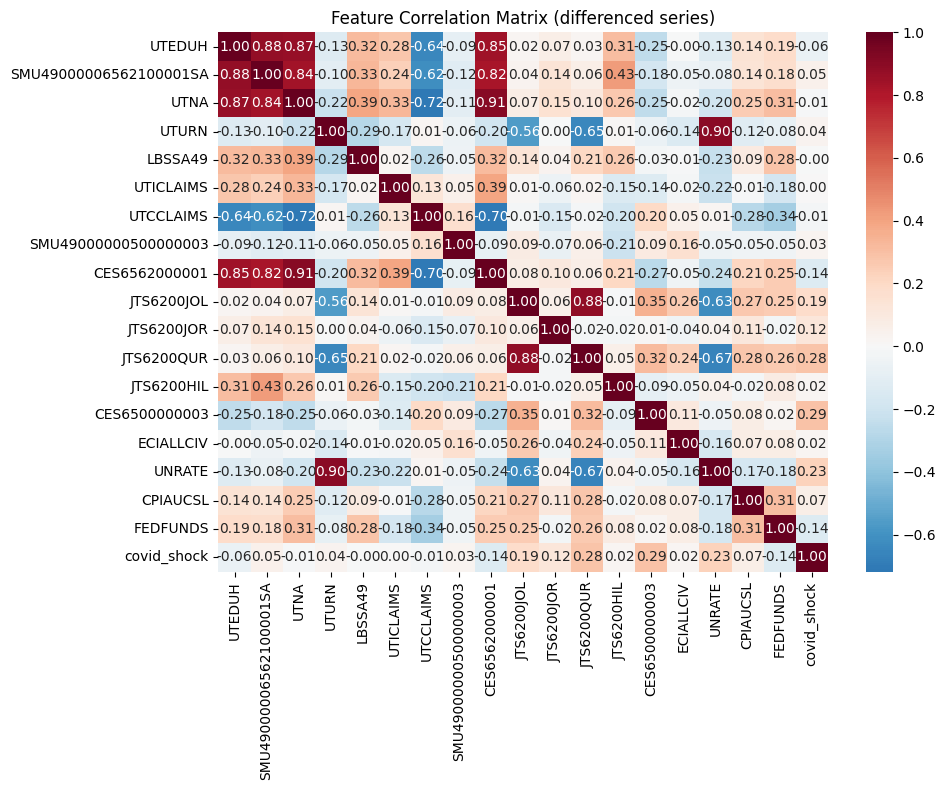

In [9]:
# Correlation matrix
corr = processed.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Feature Correlation Matrix (differenced series)')
plt.tight_layout()
plt.show()

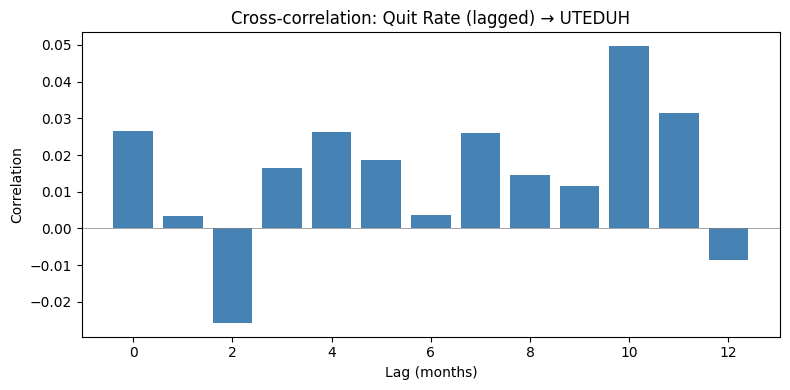

Best lag: 10 months, correlation: 0.050


In [10]:
# Cross-correlation: JOLTS quit rate vs UTEDUH at various lags
if 'JTS6200QUR' in processed.columns and 'UTEDUH' in processed.columns:
    max_lag = 12
    cross_corr = []
    for lag in range(0, max_lag + 1):
        shifted = processed['JTS6200QUR'].shift(lag)
        cc = shifted.corr(processed['UTEDUH'])
        cross_corr.append({'lag': lag, 'correlation': cc})
    
    cc_df = pd.DataFrame(cross_corr)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(cc_df['lag'], cc_df['correlation'], color='steelblue')
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('Correlation')
    ax.set_title('Cross-correlation: Quit Rate (lagged) → UTEDUH')
    ax.axhline(0, color='gray', linewidth=0.5)
    plt.tight_layout()
    plt.show()
    
    best = cc_df.loc[cc_df['correlation'].abs().idxmax()]
    print(f'Best lag: {int(best["lag"])} months, correlation: {best["correlation"]:.3f}')

In [ ]:
# TODO: Granger causality tests
# from statsmodels.tsa.stattools import grangercausalitytests
# For each feature → target pair, test if the feature Granger-causes
# changes in the target at lags 1-6.

print('Granger causality tests: implement with real data')

## Findings

- [ ] Which features have the strongest correlation with UTEDUH?
- [ ] At what lag do JOLTS indicators best predict employment changes?
- [ ] Any features to drop (near-zero predictive power)?
- [ ] Proceed to `04_model_comparison.ipynb`